In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

import re

imdb_reviews = 'https://raw.githubusercontent.com/timuroeztuerk/data-science-lecture-S24/main/Datasets/imdb_review_dataset.csv'
df = pd.read_csv(imdb_reviews)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# 1) Data Exploration. Show how many columns, positive/negative reviews, and how many missing values there are.

In [ ]:
# Columns and the shape of the dataset.
print(df.columns)
df.shape

Index(['review', 'sentiment'], dtype='object')


(50000, 2)

In [ ]:
# Missing values and Positive/Negative Reviews.
print(df.isna().sum())

df['sentiment'].value_counts()

review       0
sentiment    0
dtype: int64


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [ ]:
# 1.2) Show the first few rows of the dataset.
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# 1.3) Create a dataset summary.
df.info() # Or df.describe(), but in this case we just have two string variables so it doesnt make much sense. I asked so that you remember this step!

In [ ]:
# 1.4) How long are these reviews? Draw a histogram of the review lengths (frequency of them).
# 1.5) Visualize the negative and positive sentiments in this histogram to see the relationship between negative and positive review length.

# Create a variable for the length first.

# Then plot a histogram. I already imported matplotlib and sns for you.

df['review_length'] = df['review'].apply(len)

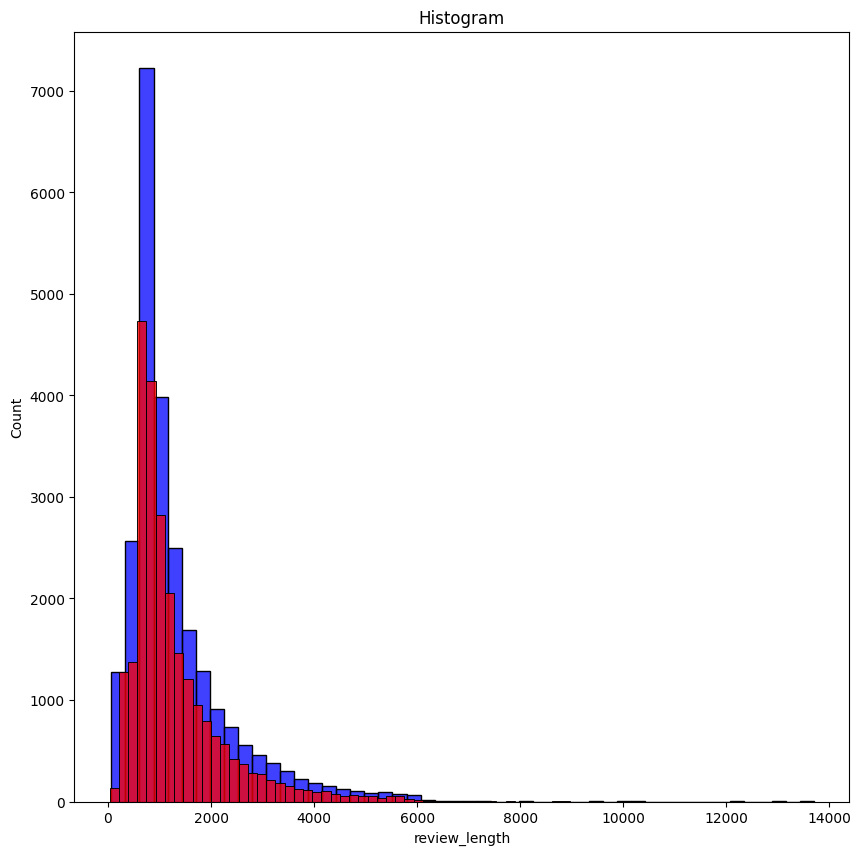

In [ ]:
plt.figure(figsize=(10,10))

sns.histplot(df[df['sentiment'] == 'positive']['review_length'],bins=50,kde=False,color='blue',label='+')
sns.histplot(df[df['sentiment'] == 'negative']['review_length'],bins=50,kde=False,color='red',label='-')

plt.title('Histogram')
#plt.xlabel
#plt.ylabel
#plt.legend

plt.show()

In [ ]:
# 2) Data Cleaning. First check if the review column is made up by sentences. Check how many dots are in each review.

df['dots'] = df['review'].apply(lambda x: x.count('.'))
df.head(15)


,review,sentiment,review_length,dots
0,One of the other reviewers has mentioned that ...,positive,1761,26
1,A wonderful little production. <br /><br />The...,positive,998,6
2,I thought this was a wonderful way to spend ti...,positive,926,6
3,Basically there's a family where a little boy ...,negative,748,10
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,15
5,"Probably my all-time favorite movie, a story o...",positive,656,6
6,I sure would like to see a resurrection of a u...,positive,726,8
7,"This show was an amazing, fresh & innovative i...",negative,934,9
8,Encouraged by the positive comments about this...,negative,681,7
9,If you like original gut wrenching laughter yo...,positive,176,2


In [ ]:
# 3) Preprocessing. Remove all punctuation, lowercase all words, and remove all stopwords. Lemmatize the dataset afterwards. Can you write the preprocessing steps in a function?
lemmatizer = WordNetLemmatizer()

In [ ]:
def function(text):
  text = re.sub(r'[^\w\s]','',text)
  text = text.lower()
  text = ' '.join([word for word in word_tokenize(text) if word not in stop_words])
  text = ' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(text)])
  return text

In [ ]:
df['review'] = df['review'].apply(function)

In [ ]:
df

,review,sentiment,review_length,dots
0,one reviewer mentioned watching 1 oz episode y...,positive,1761,26
1,wonderful little production br br filming tech...,positive,998,6
2,thought wonderful way spend time hot summer we...,positive,926,6
3,basically there family little boy jake think t...,negative,748,10
4,petter matteis love time money visually stunni...,positive,1317,15
...,...,...,...,...
49995,thought movie right good job wasnt creative or...,positive,1008,8
49996,bad plot bad dialogue bad acting idiotic direc...,negative,642,5
49997,catholic taught parochial elementary school nu...,negative,1280,17
49998,im going disagree previous comment side maltin...,negative,1234,8


In [ ]:
# Now we have a dataset that is just with words and strings. As you remember, we need to convert these strings into numbers for the machine.
# 4) Vectorize the dataset. Hint: Use the TfIdfVectorizer from sklearn. Check the sklearn documentation for more information! Are there any other vectorizers you can use?
from sklearn.feature_extraction.text import TfidfVectorizer

# initiate the model (tell computer what it is going to do)
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

In [ ]:
# Since we have our dataset in the right format, we can split it into a training and test set.
# 5) Split the dataset into a training and test datasets. Hint: Use the train_test_split function from sklearn.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=123)

In [ ]:
# 6) Train the model using Logistic Regression. (Set the maximum iteration to 100, so it converges properly)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100, random_state=123)
model.fit(X_train,y_train)

NameError: name 'X_train' is not defined

In [ ]:
# 7) Make predictions and then calculate the accuracy of your model. Check the internet for this, possibly sklearn documentation!
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.8953

In [ ]:
# Find three other models besides LogisticRegression that you can use for this excersise, and then calculate their accuracies just like above. Which one seems to be the best model?


from sklearn.svm import SVC

model = SVC()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

0.9005